Data shape: (100000, 14)
Training set shape: (80000, 12)
Testing set shape: (20000, 12)

=== Training Base XGBoost Model ===
[0]	train-rmse:0.90620	eval-rmse:0.90914
[100]	train-rmse:0.21751	eval-rmse:0.23131
[124]	train-rmse:0.21465	eval-rmse:0.23205
Base model training time: 0.45 seconds
--- Base XGBoost Model Performance Metrics ---
RMSE: 0.23
R² Score: 0.9464
MAPE: 26.38%
Prediction Accuracy: 73.62%


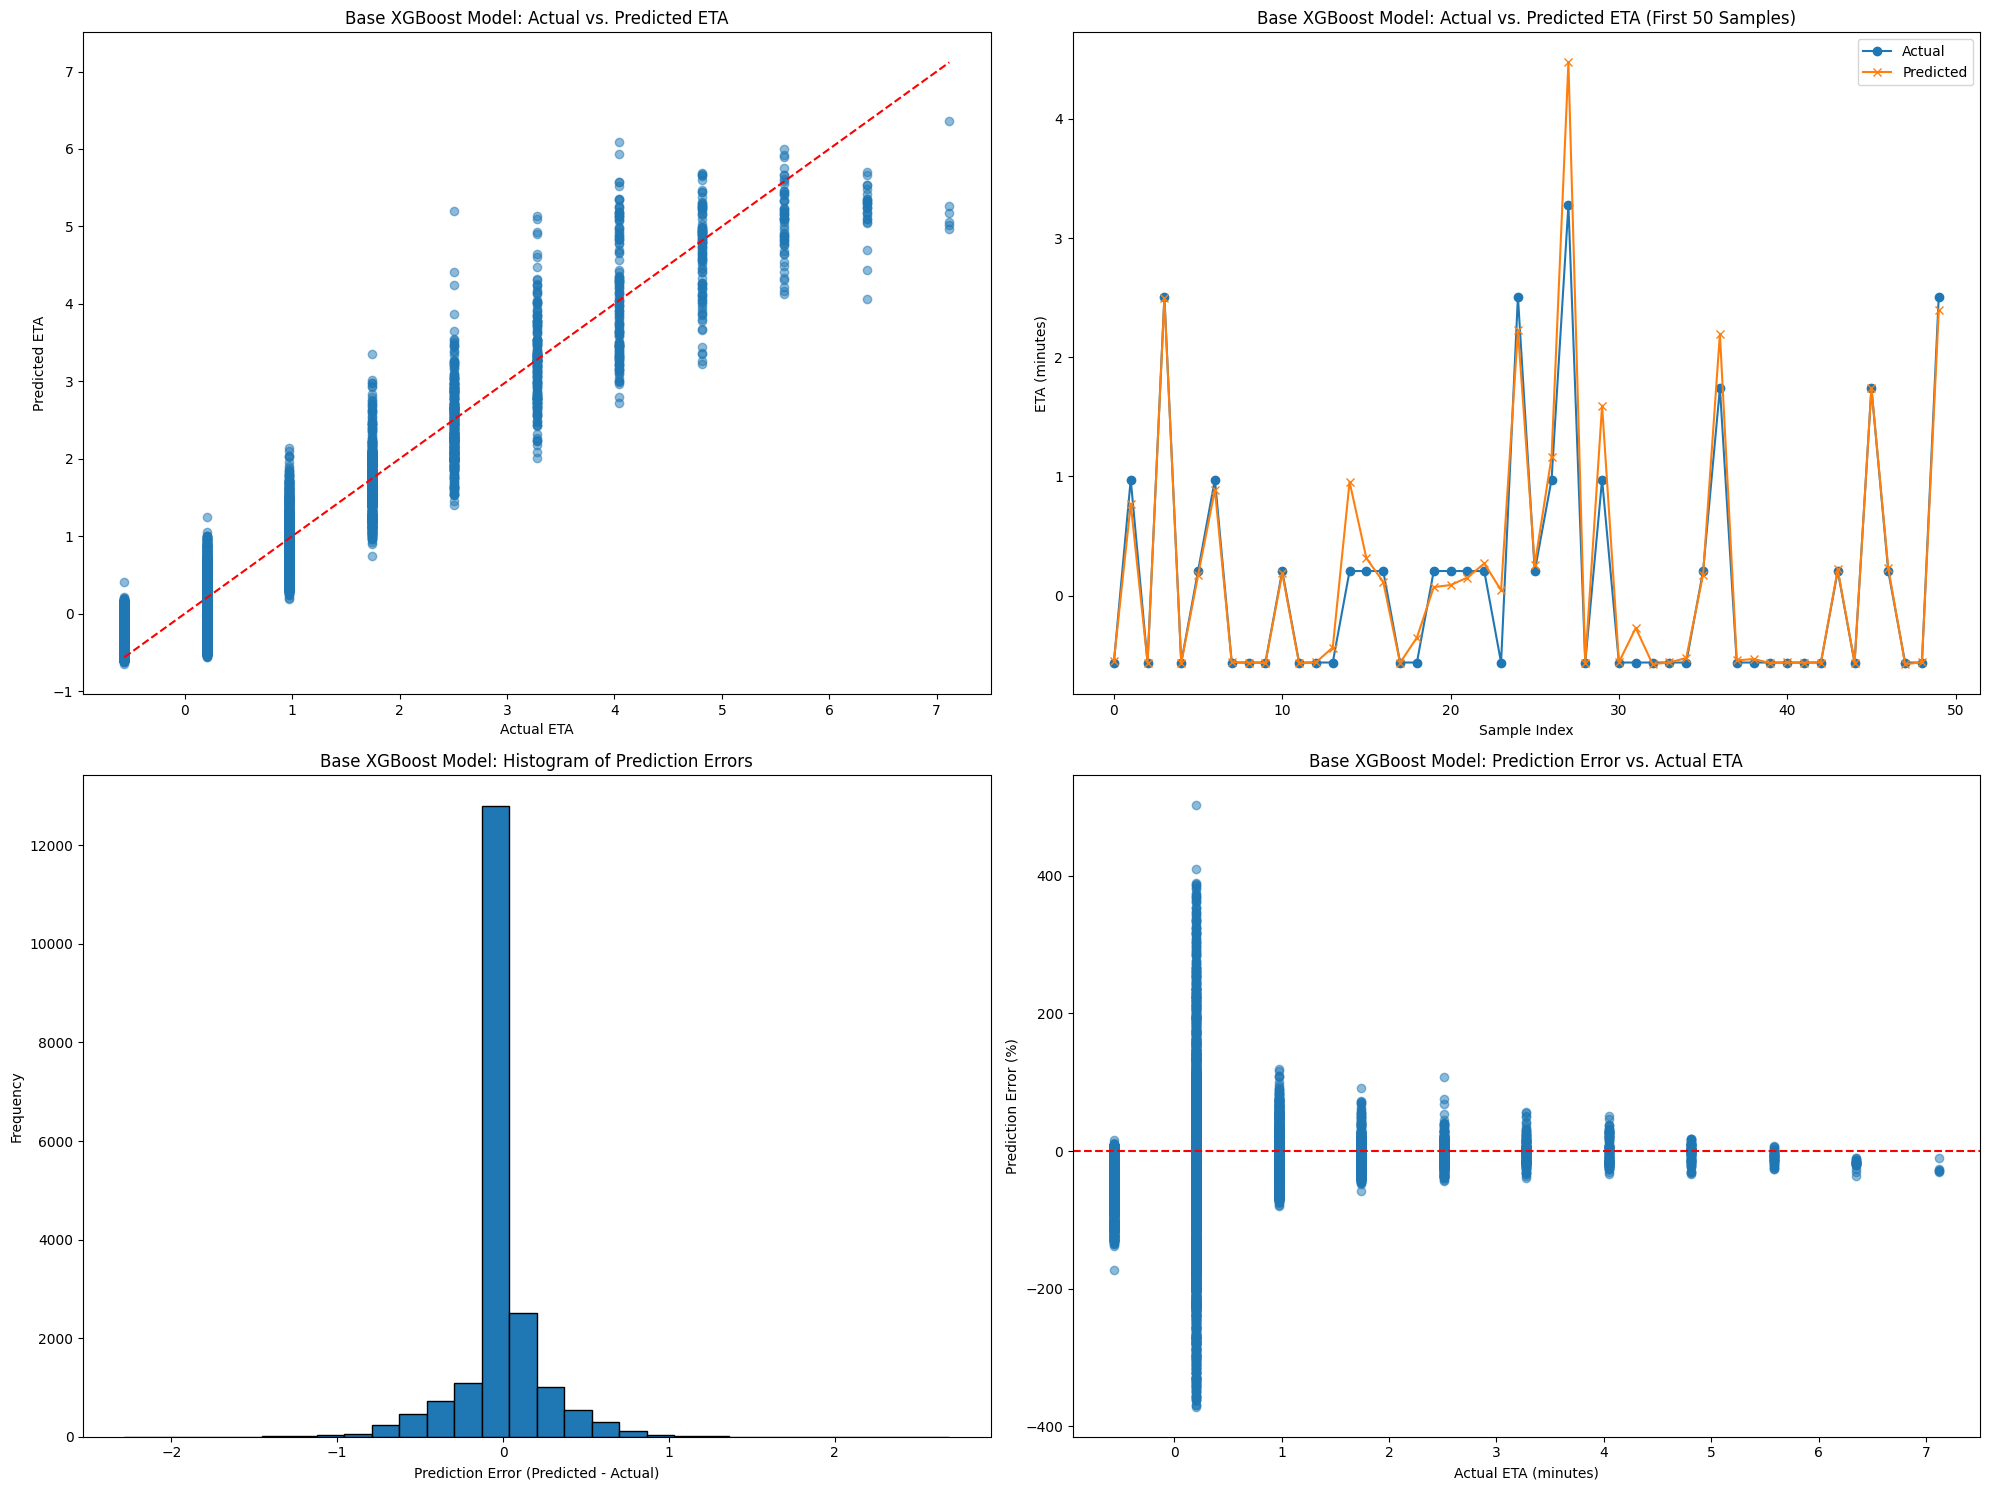


=== Performing Hyperparameter Tuning ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Hyperparameter tuning completed in 5.64 seconds
Best parameters: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best RMSE: 0.2356

=== Training Optimized XGBoost Model ===
[0]	train-rmse:0.95268	eval-rmse:0.95601
[100]	train-rmse:0.22528	eval-rmse:0.23129
[190]	train-rmse:0.21832	eval-rmse:0.23171
Optimized model training time: 0.69 seconds
--- Optimized XGBoost Model Performance Metrics ---
RMSE: 0.23
R² Score: 0.9466
MAPE: 26.35%
Prediction Accuracy: 73.65%


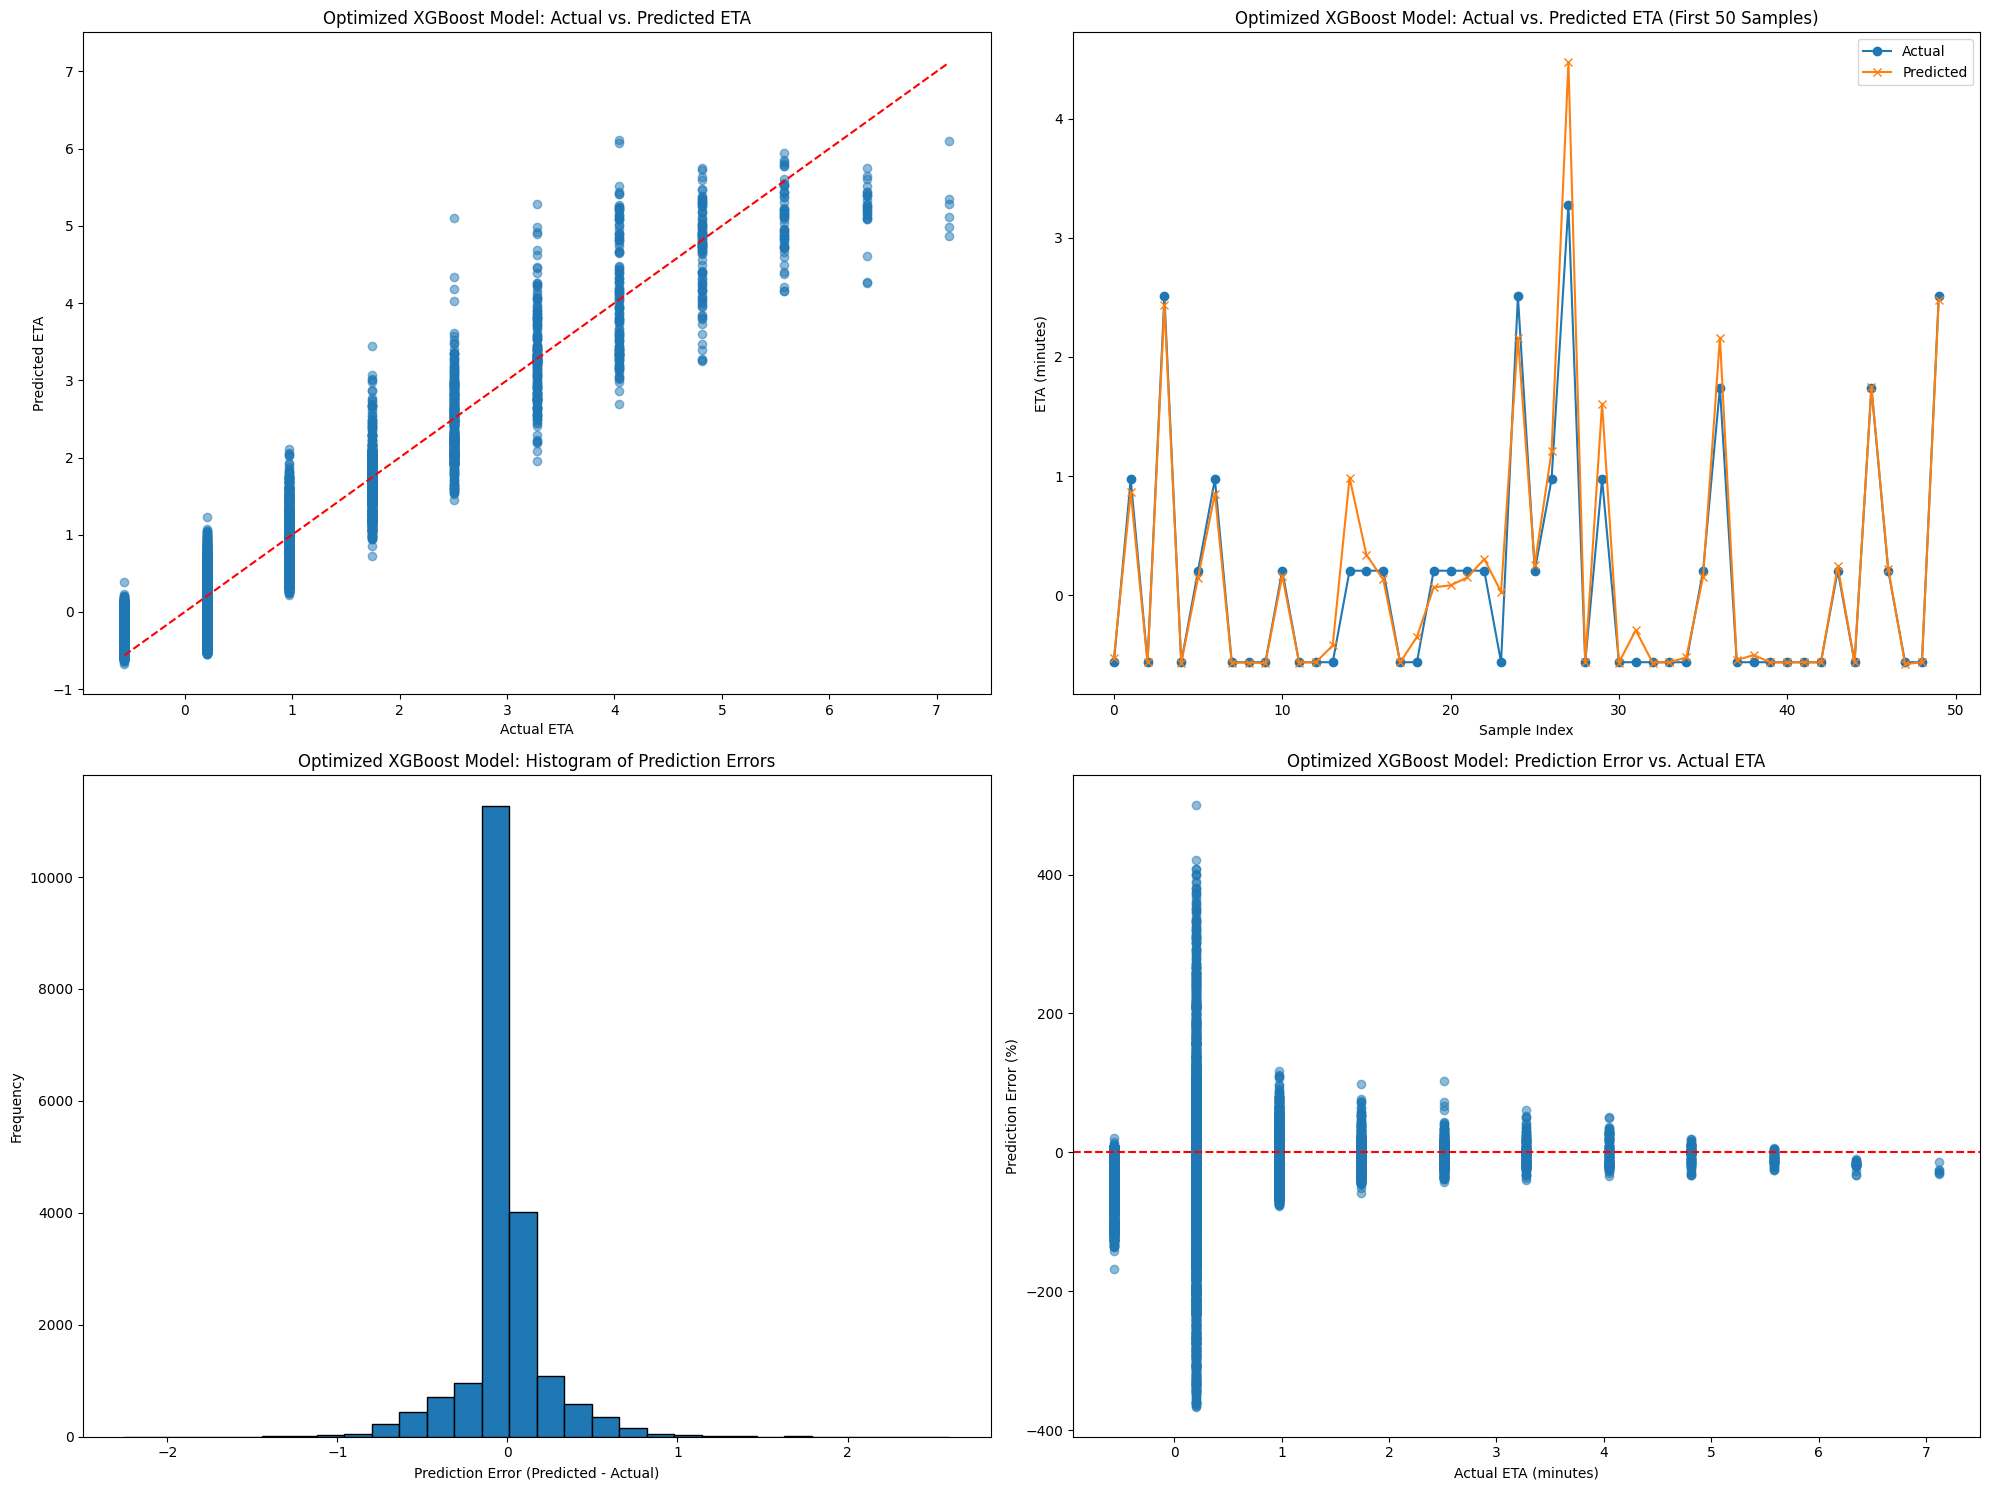


=== Performance Comparison ===
Metric               Base Model      Optimized Model Improvement    
-----------------------------------------------------------------
RMSE                 0.2321          0.2317          0.16%          
R² Score             0.9464          0.9466          0.02%          
MAPE                 26.3794         26.3524         0.10%          
Accuracy             73.6206         73.6476         0.04%          
Training Time (s)    0.4475          0.6935          -54.97%        


<Figure size 1200x800 with 0 Axes>

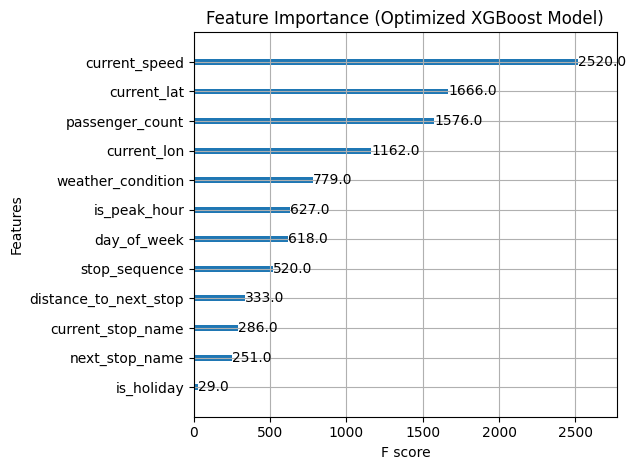

c:\Users\cheng\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== Calculating SHAP Values for XGBoost Model ===


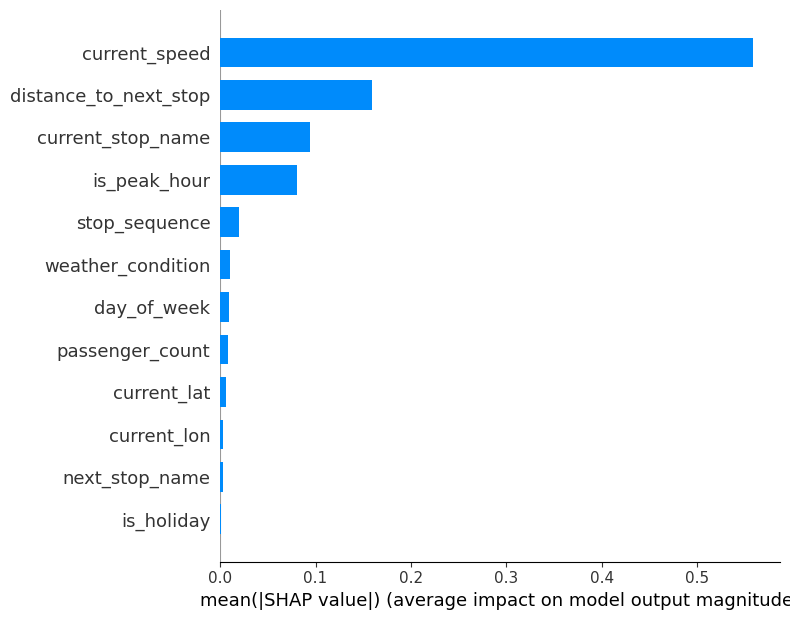

IndexError: index 7660 is out of bounds for axis 0 with size 50

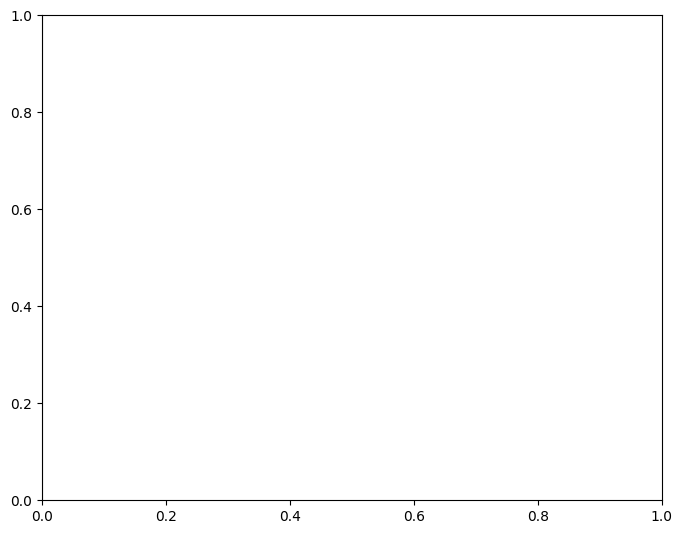

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('bus_eta_standard_scaled.csv')
print("Data shape:", df.shape)

# Selecting features and target variable
X = df.drop(columns=['timestamp', 'eta_minutes'])  # Features
y = df['eta_minutes']  # Target

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Function to evaluate and visualize model performance (same as in your original code)
def evaluate_model(model, X_test, y_test, model_name):
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    accuracy = 100 - mape
    
    print(f"--- {model_name} Performance Metrics ---")
    print(f'RMSE: {rmse:.2f}')
    print(f'R² Score: {r2:.4f}')
    print(f"MAPE: {mape:.2f}%")
    print(f"Prediction Accuracy: {accuracy:.2f}%")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # Scatter plot of actual vs predicted
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', linestyle='--')
    axes[0, 0].set_xlabel("Actual ETA")
    axes[0, 0].set_ylabel("Predicted ETA")
    axes[0, 0].set_title(f"{model_name}: Actual vs. Predicted ETA")
    
    # Line plot of first 50 samples
    axes[0, 1].plot(y_test.values[:50], label="Actual", marker='o')
    axes[0, 1].plot(y_pred[:50], label="Predicted", marker='x')
    axes[0, 1].set_xlabel("Sample Index")
    axes[0, 1].set_ylabel("ETA (minutes)")
    axes[0, 1].set_title(f"{model_name}: Actual vs. Predicted ETA (First 50 Samples)")
    axes[0, 1].legend()
    
    # Histogram of errors
    errors = y_pred - y_test
    axes[1, 0].hist(errors, bins=30, edgecolor='black')
    axes[1, 0].set_xlabel("Prediction Error (Predicted - Actual)")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title(f"{model_name}: Histogram of Prediction Errors")
    
    # Percentage error vs actual
    percentage_error = 100 * (y_pred - y_test) / y_test
    axes[1, 1].scatter(y_test, percentage_error, alpha=0.5)
    axes[1, 1].axhline(y=0, color='r', linestyle='--')
    axes[1, 1].set_xlabel("Actual ETA (minutes)")
    axes[1, 1].set_ylabel("Prediction Error (%)")
    axes[1, 1].set_title(f"{model_name}: Prediction Error vs. Actual ETA")
    
    plt.tight_layout()
    plt.show()
    
    return {
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'accuracy': accuracy,
        'predictions': y_pred
    }

# Step 1: Create a basic XGBoost model
print("\n=== Training Base XGBoost Model ===")

# Create DMatrix objects for faster training
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Base parameters
base_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'eta': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1
}

# Set up evaluation watchlist
watchlist = [(dtrain, 'train'), (dtest, 'eval')]

# Train the base model and measure time
start_time = time.time()
base_model = xgb.train(
    base_params,
    dtrain,
    num_boost_round=1000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=100
)
base_training_time = time.time() - start_time
print(f"Base model training time: {base_training_time:.2f} seconds")

# Evaluate the base model
base_results = evaluate_model(base_model, dtest, y_test, "Base XGBoost Model")

# Step 2: Hyperparameter tuning with RandomizedSearchCV
print("\n=== Performing Hyperparameter Tuning ===")

# Create the XGBoost model for tuning
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    verbosity=0
)

# Define the hyperparameter search space
param_dist = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.1, 0.5, 1, 5]
}

# RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Perform the hyperparameter tuning
start_time = time.time()
random_search.fit(X_train, y_train)
tuning_time = time.time() - start_time

print(f"\nHyperparameter tuning completed in {tuning_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best RMSE: {np.sqrt(-random_search.best_score_):.4f}")

# Step 3: Train the optimized model with the best parameters
print("\n=== Training Optimized XGBoost Model ===")

# Get the best parameters
best_params = random_search.best_params_.copy()
best_params['objective'] = 'reg:squarederror'
best_params['eval_metric'] = 'rmse'

# Extract n_estimators and remove it from params (it's used differently in xgb.train)
n_estimators = best_params.pop('n_estimators')

# Create DMatrix objects again
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up evaluation watchlist
watchlist = [(dtrain, 'train'), (dtest, 'eval')]

# Train the optimized model
start_time = time.time()
optimized_model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=n_estimators,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=100
)
optimized_training_time = time.time() - start_time
print(f"Optimized model training time: {optimized_training_time:.2f} seconds")

# Evaluate the optimized model
optimized_results = evaluate_model(optimized_model, dtest, y_test, "Optimized XGBoost Model")

# Compare the performance of base and optimized models
print("\n=== Performance Comparison ===")
print(f"{'Metric':<20} {'Base Model':<15} {'Optimized Model':<15} {'Improvement':<15}")
print("-" * 65)
metrics = [
    ('RMSE', base_results['rmse'], optimized_results['rmse'], 
     f"{(base_results['rmse'] - optimized_results['rmse'])/base_results['rmse']*100:.2f}%"),
    ('R² Score', base_results['r2'], optimized_results['r2'], 
     f"{(optimized_results['r2'] - base_results['r2'])/abs(base_results['r2'])*100:.2f}%"),
    ('MAPE', base_results['mape'], optimized_results['mape'], 
     f"{(base_results['mape'] - optimized_results['mape'])/base_results['mape']*100:.2f}%"),
    ('Accuracy', base_results['accuracy'], optimized_results['accuracy'], 
     f"{(optimized_results['accuracy'] - base_results['accuracy'])/base_results['accuracy']*100:.2f}%"),
    ('Training Time (s)', base_training_time, optimized_training_time, 
     f"{(base_training_time - optimized_training_time)/base_training_time*100:.2f}%")
]

for metric, base, optimized, improvement in metrics:
    print(f"{metric:<20} {base:<15.4f} {optimized:<15.4f} {improvement:<15}")

# Feature importance plot
plt.figure(figsize=(12, 8))
xgb.plot_importance(optimized_model, max_num_features=20)
plt.title('Feature Importance (Optimized XGBoost Model)')
plt.tight_layout()
plt.show()

# SHAP values for improved feature importance interpretation (if shap is installed)
try:
    import shap
    print("\n=== Calculating SHAP Values for XGBoost Model ===")
    
    # Create explainer
    explainer = shap.TreeExplainer(optimized_model)
    
    # Calculate SHAP values for test set
    X_test_dmatrix = xgb.DMatrix(X_test)
    shap_values = explainer.shap_values(X_test_dmatrix)
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X_test.columns)
    
    # Detail plot of top 50 samples
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_test.iloc[:50], feature_names=X_test.columns)
    
except ImportError:
    print("SHAP package not installed. Skipping SHAP analysis.")
    print("You can install it with: pip install shap")

# Save the optimized model
optimized_model.save_model('xgboost_optimized_model.json')
print("Optimized XGBoost model saved as 'xgboost_optimized_model.json'")

# Create a unified comparison between XGBoost, LightGBM and Neural Network (placeholder)
print("\n=== Model Comparison ===")
print("Note: Run all model scripts and fill in the actual values")
print(f"{'Metric':<20} {'XGBoost':<15} {'LightGBM':<15} {'Neural Network':<15}")
print("-" * 70)
print(f"{'RMSE':<20} {optimized_results['rmse']:<15.4f} {'<LightGBM>':<15} {'<NN>':<15}")
print(f"{'R² Score':<20} {optimized_results['r2']:<15.4f} {'<LightGBM>':<15} {'<NN>':<15}")
print(f"{'MAPE':<20} {optimized_results['mape']:<15.4f} {'<LightGBM>':<15} {'<NN>':<15}")
print(f"{'Accuracy':<20} {optimized_results['accuracy']:<15.4f} {'<LightGBM>':<15} {'<NN>':<15}")
print(f"{'Training Time (s)':<20} {optimized_training_time:<15.4f} {'<LightGBM>':<15} {'<NN>':<15}")